# Business Planning & Sales Prediction Using Key Business Features
## Planning Overview
This report develops a machine learning model for product sales prediction based on key business metrics. The model supports the business with planning and predicting sales changes in response to changes in Price, Promotions Spend, along with the Region, SKU, and Brand. The report evaluates regression and decision tree models, using the Mean Absolute Error (MAE) as the primary model comparison metric.
### Key Objectives
- Build a model to predict sales based on Price, Promotions Spend, Region, Brand and SKU.
- Apply the Mean Absolute Error (MAE) as the model measurement score, aiming for a minimum target of 30% of the mean/median.
- Create a deployable model package for production.
- Provide interpretable results for business stakeholders.
### Results Summary
- #### Model Comparison

> | Model | Description | MAE Value | MAE % of the Mean |
> |-----|-----|-----|-----|
> | Regression (OLS)| OLS regression model|161.463 |46.921%|
> | Regression (WLS)| Weighted regression model|160.015 |46.500%|
> | Random Forest Regressor| Initial random forest|109.645 |31.862%|
> | Gradient Boosting Regressor| Initial gradient boosting regressor|115.518 |33.569%|
> | Random Forest Regressor| Optimized random forest|106.471 |31.862%|
> | Gradient Boosting Regressor| Optimized gradient boosting regressor|99.317 |28.861%|


- #### Champion Model Packaged for Production
  Optimized Gradient Boosting Regression selected based on:
  - Lowest MAE percentage of the mean.
  - High Interpretability for stakeholders.
  - Meets performance and prediction targets

## Data Health Audit
Before analysis or building models, the data was audited for cleanliness and formatting errors.
- Data Granularity: \
      Data is aggregated at the month level for each SKU, brand, and region.

- Records & Features: \
      Data contains ~11,000 rows and 7 features.

- Target: \
      Target feature is Sales Units.

- Duplicates & Missing Values (Nulls): \
      No identical or duplicate rows, and no missing values.

- Features Overview:

| Feature | Description |
|:----------|:-----------|
| Region | Region of sales|
| Brand | Brand of the product|
| SKU | SKU the brand|
| Sales Units | No of units sold|
| Sales Value | Total sales volume|
| Net Price | Price sold|
| Trade Spend | Promotions spend|

In [91]:
%%html
<style>
table {float: left}
p {clear:both}
</style>

## Data Import & Cleaning

In [110]:
# Detect the encoding automatically using the chardet library:
import pandas as pd
import chardet
with open("./sales_dataset.csv", "rb") as f:
    result = chardet.detect(f.read(100000))

# Read file
df = pd.read_csv('./sales_dataset.csv')
print(df.shape)

# Sales df
sales_df = df[df['Brand'] == 'BrandB']
display(sales_df.head())
print(sales_df.isna().sum())

(11232, 7)


,Region,Brand,SKU,Sales_Units,Sales_Value,Net_Price,Promotion_Spend
3,CENTRAL,BrandB,BrandB_SKU1,216.583770,15986.585046,73.812479,13484.104001
4,CENTRAL,BrandB,BrandB_SKU2,272.920195,22565.283219,82.680885,13484.104001
5,CENTRAL,BrandB,BrandB_SKU3,61.971430,4985.227397,80.443962,13484.104001
12,EAST,BrandB,BrandB_SKU1,245.494601,18050.340190,73.526424,12571.966319
13,EAST,BrandB,BrandB_SKU2,123.138806,9234.703455,74.994259,12571.966319


Region             0
Brand              0
SKU                0
Sales_Units        0
Sales_Value        0
Net_Price          0
Promotion_Spend    0
dtype: int64


## Exploratory Analysis
### Feature Distribution & Feature Correlation Testing:

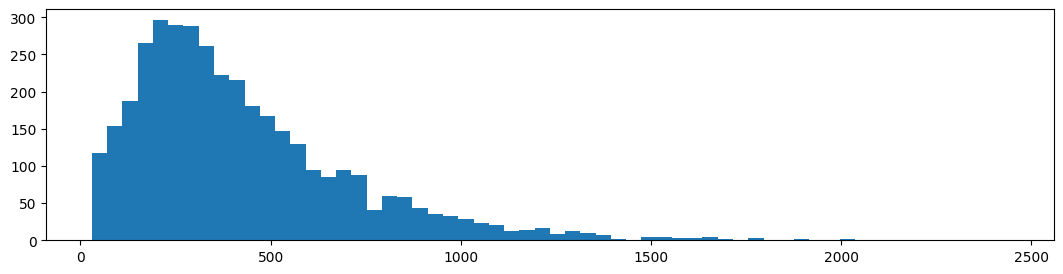

np.float64(1.576781265241166)

In [114]:
import matplotlib.pyplot as plt
import scipy.stats as stats

plt.figure(figsize=(13, 3))
plt.hist(sales_df['Sales_Units'], bins=60)
plt.show()
stats.skew(sales_df['Sales_Units'])

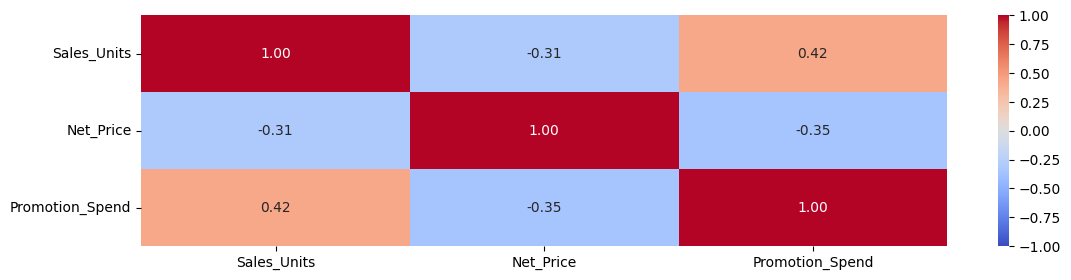

<Figure size 1300x500 with 0 Axes>

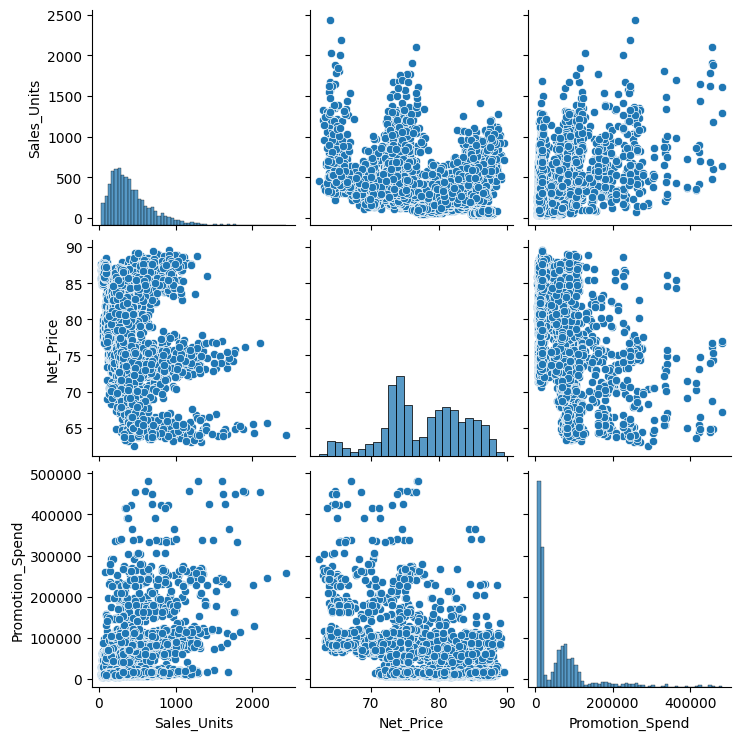

In [115]:
import seaborn as sns

corr_df = sales_df[['Sales_Units', 'Net_Price', 'Promotion_Spend']]

# Correlation using spearman to account for skewness
corr_matrix = corr_df.corr(method='pearson', numeric_only=True)

plt.figure(figsize=(13, 3))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', vmin=-1, vmax=1)
plt.show()

plt.figure(figsize=(13, 5))
sns.pairplot(corr_df)
plt.show()

## Data Preprocessing and Splitting

In [3]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import numpy as np

model_df = sales_df.drop('Sales_Value', axis=1)
model_df = pd.get_dummies(model_df, dtype=int, drop_first=True)
display(model_df.head())

y = model_df['Sales_Units']
x = model_df.iloc[:, 1:]
x_train, x_test, y_train, y_test = train_test_split(x, y, train_size=0.8, test_size=0.2, random_state=6)

y_train_log = np.log1p(y_train)

,Sales_Units,Net_Price,Trade_Spend,Region_EAST,Region_METRO_DELHI,Region_METRO_MUMBAI,Region_NORTH,Region_NORTHEAST,Region_SOUTH,Region_WEST,SKU_BrandB_SKU2,SKU_BrandB_SKU3
3,216.583770,73.812479,13484.104001,0,0,0,0,0,0,0,0,0
4,272.920195,82.680885,13484.104001,0,0,0,0,0,0,0,1,0
5,61.971430,80.443962,13484.104001,0,0,0,0,0,0,0,0,1
12,245.494601,73.526424,12571.966319,1,0,0,0,0,0,0,0,0
13,123.138806,74.994259,12571.966319,1,0,0,0,0,0,0,1,0


## Model Exploration
Multiple models were explored to choose the best fit based on the features andlowest MAE for each model.
- Naive Guess Benchmark: \
    Represents the baseline(i.e minimum) error rate. This uses the error rate resulting from sales prediction using the median value. Sales distribution is skewed, hence the use of median which provides a better measure of the distribution center. Error rate here was 63.972%.
- OLS & WeightedLS: \
    MAE percentage for the OLS model was 46.921%. Reviewing the residuals, the model appeared to struggle with larger values at the tail of Sales. The next model attempted to resolve this with weights. The weighted model resulted in a MAE percentage of 46.921%, which despite being a slight improvement on the non-weighted model, was still a high error rate.
- Gradient Boosting and Random Forest: \
    Initial models for Random forest and gradient boost produced 31.862% MAE and 33.569% MAE respectively. These were good improvements from previous models, with room to optimize for even lower error rates.

### Naive Benchmark

In [60]:
# Naive Guess benchmark for Mae
from sklearn.metrics import mean_absolute_error

naive_guess = np.median(y_test)
naive_predictions = np.full(shape=len(y_test), fill_value=naive_guess)

naive_mae = mean_absolute_error(y_test, naive_predictions)
print(f'Naive Guess: {naive_guess:.3f} \nNaive Baseline Mae: {naive_mae:.3f} \nNaive Baseline Mae%: {(naive_mae/naive_guess)*100:.3f}%')

Naive Guess: 344.118 
Naive Baseline Mae: 220.138 
Naive Baseline Mae%: 63.972%


### Regression (OLS)

In [61]:
# OLS
import statsmodels.api as sm

x_train_wc = sm.add_constant(x_train)

ols_model = sm.OLS(y_train_log, x_train_wc).fit()
print(ols_model.summary())

from sklearn.metrics import mean_absolute_error
ypred_ols = ols_model.predict(sm.add_constant(x_test, has_constant='add'))
ypred_ols = np.expm1(ypred_ols)
mae_ols = mean_absolute_error(y_test, ypred_ols)
print(f'\nOLS MAE: {mae_ols:.3f} \nOLS MAE%: {(mae_ols/naive_guess)*100:.3f}%')

                            OLS Regression Results                            
Dep. Variable:            Sales_Units   R-squared:                       0.490
Model:                            OLS   Adj. R-squared:                  0.488
Method:                 Least Squares   F-statistic:                     260.1
Date:                Wed, 22 Jul 2026   Prob (F-statistic):               0.00
Time:                        19:19:26   Log-Likelihood:                -2200.7
No. Observations:                2995   AIC:                             4425.
Df Residuals:                    2983   BIC:                             4498.
Df Model:                          11                                         
Covariance Type:            nonrobust                                         
                          coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------
const                   8.8413    

### Regression (WLS)

In [62]:
# Weighted ls
import numpy as np

errors = np.abs(ols_model.resid) # errors as abs of residuals
variance_model = sm.OLS(errors, x_train_wc).fit() # variance model from abs residuals and X with constant
estimated_variance = variance_model.fittedvalues ** 2
weights = 1/(estimated_variance+ 1e-5)
wls_model = sm.WLS(y_train_log, x_train_wc, weights=weights).fit()
print(wls_model.summary())

ypred_wls = wls_model.predict(sm.add_constant(x_test, has_constant='add'))
ypred_wls = np.expm1(ypred_wls)
mae_wls = mean_absolute_error(y_test, ypred_wls)
print(f'\nWLS MAE: {mae_wls:.3f} \nWLS MAE%: {(mae_wls/naive_guess)*100:.3f}%')

                            WLS Regression Results                            
Dep. Variable:            Sales_Units   R-squared:                       0.512
Model:                            WLS   Adj. R-squared:                  0.511
Method:                 Least Squares   F-statistic:                     285.1
Date:                Wed, 22 Jul 2026   Prob (F-statistic):               0.00
Time:                        19:19:55   Log-Likelihood:                -2014.6
No. Observations:                2995   AIC:                             4053.
Df Residuals:                    2983   BIC:                             4125.
Df Model:                          11                                         
Covariance Type:            nonrobust                                         
                          coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------
const                   8.9993    

### Initial Random Forest and Gradient Boosting

In [119]:
# Test Random Forest and Gradient Boosting
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

rf = RandomForestRegressor(random_state=42)
gb = GradientBoostingRegressor(n_estimators=300, 
    learning_rate=0.2, 
    max_depth=5,
    max_features=None,
    random_state=42)

rf.fit(x_train, y_train_log)
gb.fit(x_train, y_train_log)

ypred_rf = np.expm1(rf.predict(x_test))
mae_rf = mean_absolute_error(y_test, ypred_rf)
print(f'\nRandom Forest MAE: {mae_rf:.3f} \nRandom Forest MAE%: {(mae_rf/naive_guess)*100:.3f}%')

ypred_gb = np.expm1(gb.predict(x_test))
mae_gb = mean_absolute_error(y_test, ypred_gb)
print(f'\nGradient Boosting MAE: {mae_gb:.3f} \nGradient Boosting MAE%: {(mae_gb/naive_guess)*100:.3f}%')


Random Forest MAE: 109.645 
Random Forest MAE%: 31.862%

Gradient Boosting MAE: 101.842 
Gradient Boosting MAE%: 29.595%


## HyperParameter Optimization

### Random Forest

In [76]:
# Random Forest has the better MAE, so we are goung with random Forest
from sklearn.model_selection import GridSearchCV

rfr = RandomForestRegressor(random_state=42)

param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 5, 7, 10, 13, 15, 18, None],
    'min_samples_leaf': [2, 5, 7, 10],
    'max_features': ['sqrt', 0.4, 0.7, None]
}

grid_search = GridSearchCV(
    estimator=rfr,
    param_grid=param_grid,
    cv=5,
    scoring='neg_mean_squared_error'
    # n_jobs=-1
)

display(grid_search.fit(x_train, y_train_log))

display(grid_search.best_params_)

best_rfr = grid_search.best_estimator_

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestR...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'max_depth': [3, 5, ...], 'max_features': ['sqrt', 0.4, ...], 'min_samples_leaf': [2, 5, ...], 'n_estimators': [100, 200, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'neg_mean_squared_error'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time 

{'max_depth': 13,
 'max_features': 'sqrt',
 'min_samples_leaf': 2,
 'n_estimators': 300}

In [69]:
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import root_mean_squared_error

rft = RandomForestRegressor(max_depth=13, max_features='sqrt', min_samples_leaf=2, n_estimators=300, random_state=42)
rft.fit(x_train, y_train_log)
print(f'Random Forest MAE: {mean_absolute_error(y_test, np.expm1(rft.predict(x_test))):.3f}')
print(f'Random Forest RMSE: {root_mean_squared_error(y_test, np.expm1(rft.predict(x_test))):.3f}')

Random Forest MAE: 106.471
Random Forest RMSE: 161.732


### Gradient Boosting

In [124]:
from sklearn.model_selection import GridSearchCV

gbr = GradientBoostingRegressor(random_state=42)

param_grid_gb = {
    'n_estimators': [100, 200, 300, 400],
    'max_depth': [3, 5, 7, 10, None],
    'min_samples_leaf': [2, 5, 7, 10],
    # 'max_features': ['sqrt', 0.4, 0.7, None],
    'learning_rate': [0.01, 0.05, 0.1, 0.2]
}

grid_search_gb = GridSearchCV(
    estimator=gbr,
    param_grid=param_grid_gb,
    cv=5,
    scoring='neg_mean_squared_error'
    # n_jobs=-1
)

display(grid_search_gb.fit(x_train, y_train_log))

display(grid_search_gb.best_params_)

best_gbr = grid_search_gb.best_estimator_

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",GradientBoost...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'learning_rate': [0.01, 0.05, ...], 'max_depth': [3, 5, ...], 'min_samples_leaf': [2, 5, ...], 'n_estimators': [100, 200, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'neg_mean_squared_error'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time 

{'learning_rate': 0.2,
 'max_depth': 5,
 'min_samples_leaf': 2,
 'n_estimators': 300}

## Model Package for Production

In [137]:
import numpy as np
import pandas as pd
import joblib
from sklearn.compose import ColumnTransformer, TransformedTargetRegressor
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor

# Data setup
pipeline_df = sales_df.drop('Sales_Value', axis=1)
y_pipeline = pipeline_df['Sales_Units']
x_pipeline = pipeline_df.iloc[:, [0, 1, 2, 4, 5]]
x_train_p, x_test_p, y_train_p, y_test_p = train_test_split(x_pipeline, y_pipeline, train_size=0.8, test_size=0.2, random_state=6)

# Preprocessing pipeline. Onehot encode categories and pass numeric data raw
categorical_features = ['Region', 'Brand', 'SKU']
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), categorical_features)
    ],
    remainder='passthrough' # Send numericals unscaled
)

# Main estimator: Target transformer + Random forest
optimized_gb = GradientBoostingRegressor(
    n_estimators=300, 
    learning_rate=0.2, 
    max_depth=7,
    min_samples_leaf=2,
    random_state=42
)

# log1p transformation to fix skew
target_transformer = TransformedTargetRegressor(
    regressor=optimized_gb,
    func=np.log1p,      
    inverse_func=np.expm1 
)

# Assemble pipeline
production_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', target_transformer)
])

# Train model
production_pipeline.fit(x_train_p, y_train_p)

# Validate
test_preds = production_pipeline.predict(x_test_p)
final_mae = mean_absolute_error(y_test_p, test_preds)
print(f"Final Production MAE: {final_mae:.3f} \nFinal Production MAE%: {(final_mae/naive_guess)*100:.3f}%")

# Save production pipeline
joblib.dump(production_pipeline, 'model/pipeline_model.joblib')

Final Production MAE: 98.236 
Final Production MAE%: 28.547%


['pipeline_model.joblib']

## Appendix (Additional observations)